## Part B: Data Preparation and Exploratory Analysis

In the health insurance industry, companies rely heavily on data analytics to understand how different
customer characteristics influence insurance costs. Factors such as age, health indicators, lifestyle
habits, and geographical location can significantly influence the annual insurance charges assigned
to an individual.\
\
For this project, you are provided with ”medical insurance dataset.csv” dataset containing information
about individuals and their corresponding annual medical insurance charges. The goal is to use
data analysis and machine learning techniques in Python to explore relationships within the dataset,
uncover patterns, and build predictive models that can estimate insurance charges.

The dataset contains the following parameters:
| Parameter | Description | Content Type |
| ---------- | --------- | ------------ |
| age | Age in years | integer |
| gender | Male or Female | integer (1 or 2) |
| bmi | Body mass index | float |
| no of children | Number of children | integer |
| smoker | Whether smoker or not | integer (0 or 1) |
| region | Which US region - NW, NE, SW, SE | integer (1,2,3 or 4 respectively) |
| charges | Annual | Insurance | charges in USD | float |

*Table 1: Description of Dataset Variables*\
\
The objective of the project is not only to implement Python code, but also to demonstrate your
ability to investigate the dataset, uncover patterns, and support data-driven conclusions. Throughout
the analysis, you should clearly explain your observations and briefly interpret the insights obtained
from the results of your analysis and visualizations.\
\
(a) Load the dataset into a Pandas DataFrame and display the first few rows to understand the
structure of the dataset.

In [1]:
import pandas as pd
import numpy as np

df=pd.read_csv('data/raw/medical_insurance_dataset.csv')
df.head()

,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2772 non-null   str    
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   str    
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 151.7 KB


(b) Examine the dataset to determine whether there are any missing or null values in the columns.
Identify the columns affected and apply appropriate strategies to handle the missing data
depending on the datatype of the attribute. Verify the changes using `df.info()` .

In [3]:
# Convert age and smoker to integer, setting errors to NaN
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['smoker'] = pd.to_numeric(df['smoker'], errors='coerce')

# replace "?" to NaN
df.replace("?", np.nan, inplace = True)
df.head(5)

,age,gender,bmi,no_of_children,smoker,region,charges
0,19.0,1,27.900,0,1.0,3,16884.92400
1,18.0,2,33.770,1,0.0,4,1725.55230
2,28.0,2,33.000,3,0.0,4,4449.46200
3,33.0,2,22.705,0,0.0,1,21984.47061
4,32.0,2,28.880,0,0.0,1,3866.85520


In [4]:
print(df.isna().sum())

age               4
gender            0
bmi               0
no_of_children    0
smoker            7
region            0
charges           0
dtype: int64


In [5]:
df.describe()

,age,gender,bmi,no_of_children,smoker,region,charges
count,2768.000000,2772.000000,2772.000000,2772.000000,2765.000000,2772.000000,2772.000000
mean,39.109827,1.507215,30.701349,1.101732,0.203978,2.559885,13261.369959
std,14.091633,0.500038,6.129449,1.214806,0.403026,1.130761,12151.768945
min,18.000000,1.000000,15.960000,0.000000,0.000000,1.000000,1121.873900
25%,26.000000,1.000000,26.220000,0.000000,0.000000,2.000000,4687.797000
50%,39.000000,2.000000,30.447500,1.000000,0.000000,3.000000,9333.014350
75%,51.000000,2.000000,34.770000,2.000000,0.000000,4.000000,16577.779500
max,64.000000,2.000000,53.130000,5.000000,1.000000,4.000000,63770.428010


Since only 4 out of 2772 rows have missing values in the 'age' column, a simple imputation method such as filling with the median age (39) is most suitable. This preserves the distribution better than mean imputation and avoids skewing from outliers. More advanced methods like KNN or regression imputation are generally unnecessary given the very small proportion of missing data.

In [6]:
# Calculate the mean
age_mean = df['age'].mean()

# Fill NaN values with the mean
df['age'] = df['age'].fillna(age_mean)

In [7]:
# Calculate observed distribution of 'smoker' (0 and 1)
probabilities = df['smoker'].value_counts(normalize=True)
print(probabilities)

# Generate random imputations based on distribution
missing_count = df['smoker'].isna().sum()
imputed_values = np.random.choice(probabilities.index, 
                                  size=missing_count, 
                                  p=probabilities.values)

# Fill missing values
df.loc[df['smoker'].isna(), 'smoker'] = imputed_values

smoker
0.0    0.796022
1.0    0.203978
Name: proportion, dtype: float64


In [8]:
print(df.isna().sum())

age               0
gender            0
bmi               0
no_of_children    0
smoker            0
region            0
charges           0
dtype: int64


In [9]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2772 non-null   float64
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   float64
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 151.7 KB
None


(c) The `charges` column contains values with more than two decimal places. Transform the column
so that all values are rounded to two decimal places. Display the first five rows to confirm that
the update has been applied correctly.

In [ ]:
# Round to 2 decimal places all values in the 'charges' column
df['charges'] = df['charges'].round(2)
df['charges'].head()

0    16884.92
1     1725.55
2     4449.46
3    21984.47
4     3866.86
Name: charges, dtype: float64

(d) Save the cleaned and transformed dataset using your last name as the filename in CSV format.
Example: `YourLastName.csv` (e.g., `Nuwe.csv` ).

In [11]:
df.to_csv('data/cleaned/kateega.csv', index=False)
print("Cleaned dataset saved to 'data/cleaned/kateega.csv'")

Cleaned dataset saved to 'data/cleaned/kateega.csv'


(e) Using the cleaned dataset, generate appropriate visualizations to explore how different attributes may influence the insurance charges. 

<ol type="i">
    <li> Show the relationship between bmi and charges.
    <li> Compare charges for smokers and non-smokers.
    <li> Compare charges for smokers and non-smokers.
</ol>

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

df_cleaned = pd.read_csv('data/cleaned/kateega.csv')

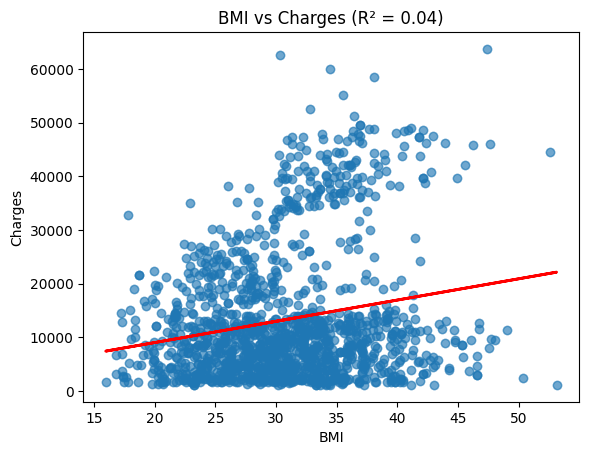

In [21]:
X = df['bmi'].values.reshape(-1, 1)
y = df['charges'].values

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Predict line
y_pred = model.predict(X)

# Calculate R^2
r2 = model.score(X, y)

# Scatter plot
plt.scatter(df['bmi'], df['charges'], alpha=0.4)
plt.plot(df['bmi'], y_pred, color='red', linewidth=2)
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.title(f'BMI vs Charges (R² = {r2:.2f})')
plt.show()

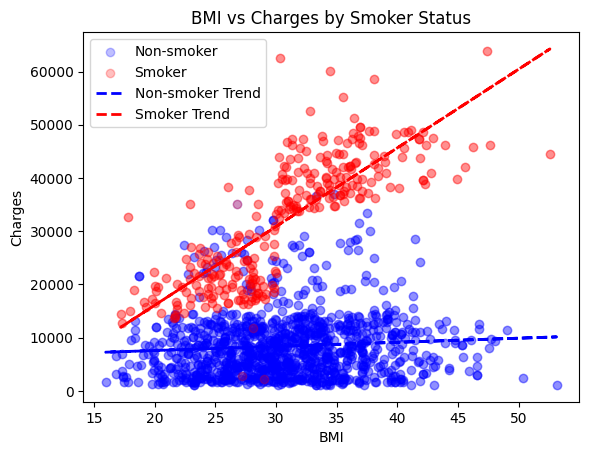

In [ ]:
# Separate smokers and non-smokers
smokers = df[df['smoker'] == 1]
non_smokers = df[df['smoker'] == 0]

# Plot non-smokers
plt.scatter(non_smokers['bmi'], non_smokers['charges'], 
            color='blue', label='Non-smoker', alpha=0.25)

# Plot smokers
plt.scatter(smokers['bmi'], smokers['charges'], 
            color='red', label='Smoker', alpha=0.25)

# Fit regression line for non-smokers
m_ns, b_ns = np.polyfit(non_smokers['bmi'], non_smokers['charges'], 1)
plt.plot(non_smokers['bmi'], m_ns*non_smokers['bmi'] + b_ns, 
         color='blue', linewidth=2, linestyle='--', label='Non-smoker Trend')

# Fit regression line for smokers
m_s, b_s = np.polyfit(smokers['bmi'], smokers['charges'], 1)
plt.plot(smokers['bmi'], m_s*smokers['bmi'] + b_s, 
         color='red', linewidth=2, linestyle='--', label='Smoker Trend')

# Labels and title
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.title('BMI vs Charges by Smoker Status')

# Add legend
plt.legend()

plt.show()

(f) Conduct the correlation analysis for the dataset (statistically and visually). Based on the correlation
results, discuss which variables appear to have stronger relationships with the insurance
charges.

In [27]:
corr = df_cleaned.corr()
corr

,age,gender,bmi,no_of_children,smoker,region,charges
age,1.000000,-0.026041,0.113045,0.037585,-0.023188,-0.007175,0.298622
gender,-0.026041,1.000000,0.042924,0.016020,0.080271,0.022213,0.062837
bmi,0.113045,0.042924,1.000000,-0.001492,0.009748,0.271119,0.199846
no_of_children,0.037585,0.016020,-0.001492,1.000000,0.006046,-0.025717,0.066442
smoker,-0.023188,0.080271,0.009748,0.006046,1.000000,0.053746,0.786639
region,-0.007175,0.022213,0.271119,-0.025717,0.053746,1.000000,0.054058
charges,0.298622,0.062837,0.199846,0.066442,0.786639,0.054058,1.000000


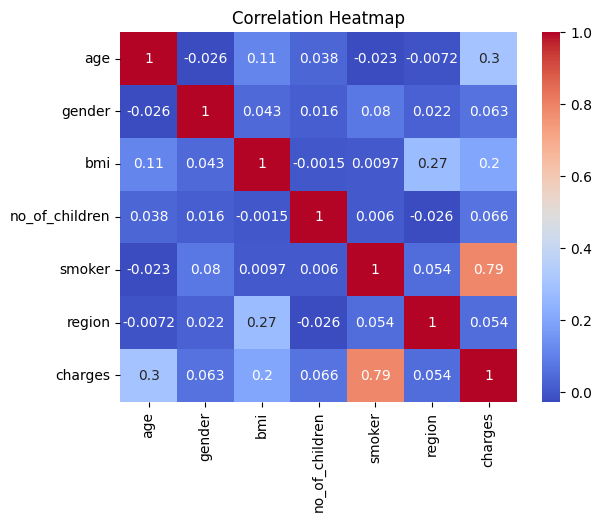

In [28]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Interpretation:
- Smoker status shows the strongest positive correlation with charges, and smokers tend to have much higher insurance costs.
- BMI has a moderate positive correlation with charges, reflecting health risk factors.
- Age also correlates positively with charges, though typically weaker than smoker status.
- Number of children and region generally show weak or negligible correlation with charges.
- Gender often has little to no correlation with medical insurance charges.

## Part C: Predictive Modeling and Analytical Insights

Using the cleaned dataset saved in Part B, build predictive models to estimate insurance charges.\
\
(a) Develop a simple linear regression model that predicts charges using only the smoker attribute.
Compute and report the R2 score of the model. Briefly comment on what this result suggests
about the importance of smoking status.

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = pd.read_csv('data/cleaned/kateega.csv')

# Data preparation
X = df[['smoker']]   # independent variable (0 = non-smoker, 1 = smoker)
y = df['charges']    # dependent variable

# Fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Compute R² score
r2 = r2_score(y, y_pred)
print("R² score:", r2)

# Inspect coefficients
print("Intercept:", model.intercept_)
print("Coefficient for smoker:", model.coef_[0])


R² score: 0.6188007987487505
Intercept: 8409.546837568065
Coefficient for smoker: 23678.263532150224


Interpretation:
- The R² score of 0.62 is high, and it shows that smoking status alone explains a large share of the variation in charges.
- This confirms that smoking is the most important single predictor of insurance costs, even without considering age, BMI, or other factors.

(b) Develop another linear regression model that predicts charges using all other attributes in the
dataset. Report the R2 score and discuss whether the model performance improves compared
to the previous model.